In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [3]:
df = pd.read_csv("housing_rates.csv")
df.head()

,Region,Price,SqFt,Bedrooms,Years,DistanceFromCity_km
0,Mumbai,471573.0,2024.0,4,54,2.16
1,Delhi,251504.0,1738.0,4,43,12.13
2,Jaipur,233064.0,2091.0,3,48,2.57
3,Chennai,329235.0,2485.0,4,39,13.84
4,Bengaluru,206046.0,1695.0,2,10,4.41


In [4]:
print("Mean\n")
print(df.mean(numeric_only=True))

Mean

Price                  253116.650
SqFt                     1722.850
Bedrooms                    2.850
Years                      27.100
DistanceFromCity_km         5.992
dtype: float64


In [15]:

print("Median\n")
print(df.median(numeric_only=True))

Median

Price                  233339.00
SqFt                     1695.00
Bedrooms                    3.00
Years                      30.50
DistanceFromCity_km         5.57
dtype: float64


In [16]:
print("Mode\n")
print(df.mode())

Mode

    Region     Price    SqFt  Bedrooms  Years  DistanceFromCity_km
0   Mumbai  155507.0  1695.0       3.0    5.0                  0.8
1      NaN  173939.0     NaN       NaN    7.0                  NaN
2      NaN  178387.0     NaN       NaN    8.0                  NaN
3      NaN  206046.0     NaN       NaN   49.0                  NaN
4      NaN  211807.0     NaN       NaN    NaN                  NaN
5      NaN  225358.0     NaN       NaN    NaN                  NaN
6      NaN  225763.0     NaN       NaN    NaN                  NaN
7      NaN  226937.0     NaN       NaN    NaN                  NaN
8      NaN  230266.0     NaN       NaN    NaN                  NaN
9      NaN  233064.0     NaN       NaN    NaN                  NaN
10     NaN  233614.0     NaN       NaN    NaN                  NaN
11     NaN  233670.0     NaN       NaN    NaN                  NaN
12     NaN  235737.0     NaN       NaN    NaN                  NaN
13     NaN  251504.0     NaN       NaN    NaN           

In [17]:
print("Variance\n")
print(df.var(numeric_only=True))

Variance

Price                  5.502057e+09
SqFt                   1.866473e+05
Bedrooms               7.657895e-01
Years                  3.933579e+02
DistanceFromCity_km    2.132355e+01
dtype: float64


In [18]:
print("Standard Deviation\n")
print(df.std(numeric_only=True))

Standard Deviation

Price                  74175.853369
SqFt                     432.026958
Bedrooms                   0.875094
Years                     19.833252
DistanceFromCity_km        4.617743
dtype: float64


In [19]:
df.describe()

,Price,SqFt,Bedrooms,Years,DistanceFromCity_km
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,253116.650000,1722.850000,2.850000,27.100000,5.992000
std,74175.853369,432.026958,0.875094,19.833252,4.617743
min,155507.000000,939.000000,1.000000,2.000000,0.500000
25%,221970.250000,1508.000000,2.750000,7.750000,2.070000
50%,233339.000000,1695.000000,3.000000,30.500000,5.570000
75%,266408.250000,2029.000000,3.000000,44.250000,8.367500
max,471573.000000,2511.000000,4.000000,58.000000,15.890000


In [20]:
corr = df.corr(numeric_only=True)

corr

,Price,SqFt,Bedrooms,Years,DistanceFromCity_km
Price,1.000000,0.442905,0.576027,0.169878,0.116750
SqFt,0.442905,1.000000,0.800553,0.114233,0.314584
Bedrooms,0.576027,0.800553,1.000000,0.204086,0.371928
Years,0.169878,0.114233,0.204086,1.000000,-0.243435
DistanceFromCity_km,0.116750,0.314584,0.371928,-0.243435,1.000000


heat map

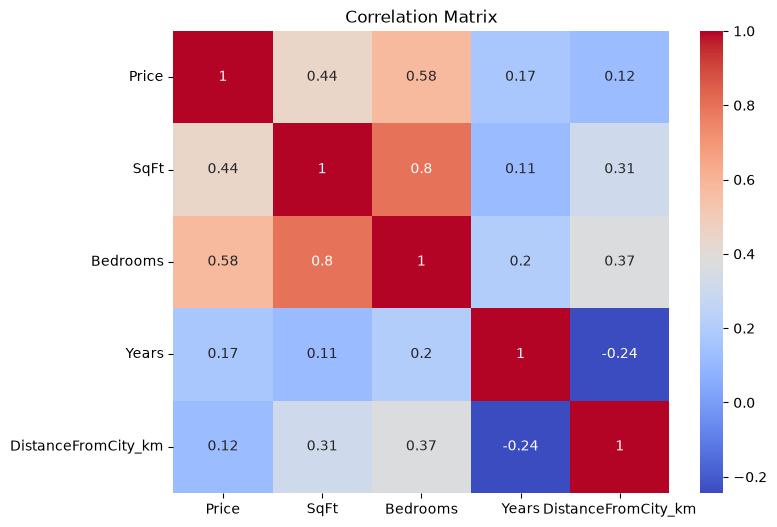

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

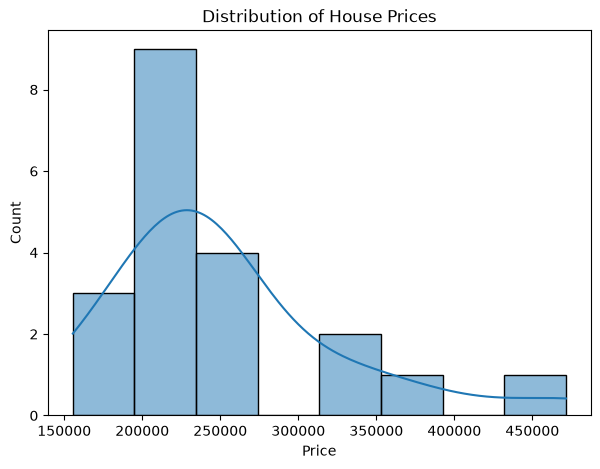

In [22]:
plt.figure(figsize=(7,5))

sns.histplot(df["Price"],
             bins=8,
             kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.show()

box plot

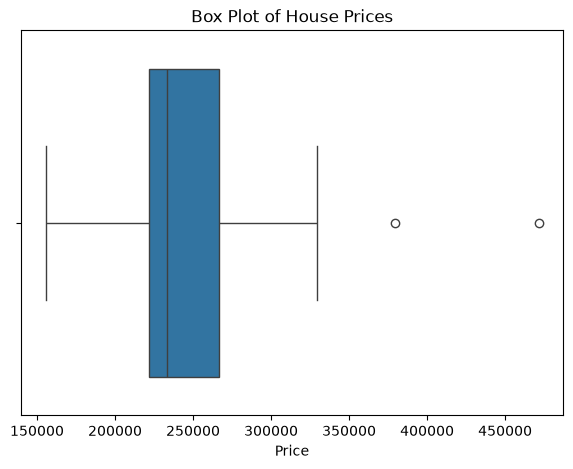

In [23]:
plt.figure(figsize=(7,5))

sns.boxplot(x=df["Price"])

plt.title("Box Plot of House Prices")

plt.show()

KDE plot

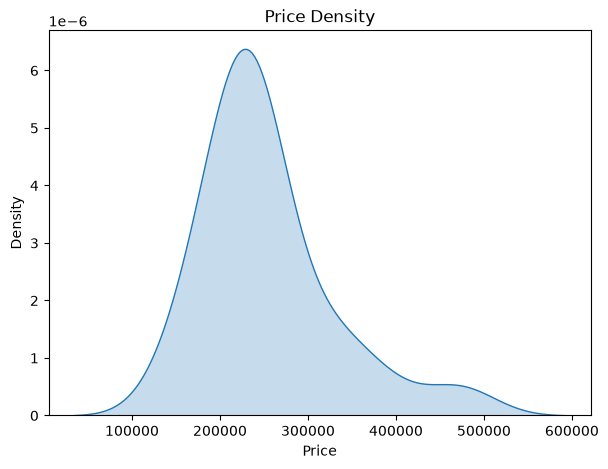

In [24]:
plt.figure(figsize=(7,5))

sns.kdeplot(df["Price"],
            fill=True)

plt.title("Price Density")

plt.show()

In [25]:
print(df["Price"].skew())

1.5957187127409493


In [26]:
sample = df.sample(n=5, random_state=42)

sample

,Region,Price,SqFt,Bedrooms,Years,DistanceFromCity_km
0,Mumbai,471573.0,2024.0,4,54,2.16
17,Mumbai,225358.0,1941.0,3,7,7.47
15,Pune,226937.0,1547.0,3,49,0.50
1,Delhi,251504.0,1738.0,4,43,12.13
8,Delhi,379413.0,1589.0,3,8,4.81


In [27]:
sample = df.sample(frac=0.3,
                   random_state=42)

sample

,Region,Price,SqFt,Bedrooms,Years,DistanceFromCity_km
0,Mumbai,471573.0,2024.0,4,54,2.16
17,Mumbai,225358.0,1941.0,3,7,7.47
15,Pune,226937.0,1547.0,3,49,0.50
1,Delhi,251504.0,1738.0,4,43,12.13
8,Delhi,379413.0,1589.0,3,8,4.81
5,Pune,324666.0,1695.0,3,2,8.81


Probability 

In [28]:
prob = len(df[df["Price"] > 300000]) / len(df)

print(prob)

0.2


In [29]:
prob = len(df[df["Bedrooms"] == 3]) / len(df)

print(prob)

0.55


In [30]:
prob = len(df[df["Region"] == "Mumbai"]) / len(df)

print(prob)

0.25


In [31]:
region_price = df.groupby("Region")["Price"].mean()

print(region_price)

Region
Bengaluru    186124.00
Chennai      279750.50
Delhi        253046.75
Jaipur       233367.00
Kolkata      241380.50
Mumbai       286235.00
Pune         275801.50
Name: Price, dtype: float64
